# Model Comparison — XGBoost vs Random Forest
Side-by-side evaluation of both trained models on the **same** val/test splits.

Loads pre-trained models from `outputs/models/` and compares metrics, threshold
behaviour, calibration, and feature importance.

In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    matthews_corrcoef, f1_score, recall_score, precision_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

from features import engineer_features, get_feature_columns, get_target_column
from evaluate import plot_confusion_matrix

sns.set_theme(style='darkgrid')

# ── Load both models ────────────────────────────────────────────────────────
xgb_saved = joblib.load('/home/james/ml-proj/predmain/outputs/models/xgb_model.pkl')
rf_saved  = joblib.load('/home/james/ml-proj/predmain/outputs/models/rf_model.pkl')

xgb_model, xgb_thresh = xgb_saved['model'], float(xgb_saved['threshold'])
rf_model,  rf_thresh  = rf_saved['model'],  float(rf_saved['threshold'])

# ── Recreate identical splits ────────────────────────────────────────────────
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df = engineer_features(df)

X = df[get_feature_columns()]
y = df[get_target_column()]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Features:  {len(get_feature_columns())}')
print(f'Split:     train {len(X_train)} / val {len(X_val)} / test {len(X_test)}')
print(f'XGBoost threshold:       {xgb_thresh}')
print(f'Random Forest threshold: {rf_thresh}')

Dropped 19 RNF rows (10000 → 9981)
Features:  9
Split:     train 7984 / val 998 / test 999
XGBoost threshold:       0.57
Random Forest threshold: 0.48


## 1 · Metric comparison

In [2]:
def evaluate(model, X, y, threshold, name):
    proba  = model.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return {
        'Model': name,
        'MCC':       round(float(matthews_corrcoef(y, y_pred)), 3),
        'F1':        round(float(f1_score(y, y_pred)), 3),
        'Recall':    round(float(recall_score(y, y_pred)), 3),
        'Precision': round(float(precision_score(y, y_pred, zero_division=0)), 3),
        'Brier':     round(float(brier_score_loss(y, proba)), 4),
        'Threshold': threshold,
    }

rows = [
    evaluate(xgb_model, X_val,  y_val,  xgb_thresh, 'XGBoost  (val)'),
    evaluate(xgb_model, X_test, y_test, xgb_thresh, 'XGBoost  (test)'),
    evaluate(rf_model,  X_val,  y_val,  rf_thresh,  'RF       (val)'),
    evaluate(rf_model,  X_test, y_test, rf_thresh,  'RF       (test)'),
]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Mean across val + test
xgb_mean = summary[summary.Model.str.startswith('XGB')][['MCC','F1','Recall','Precision','Brier']].mean()
rf_mean  = summary[summary.Model.str.startswith('RF')][['MCC','F1','Recall','Precision','Brier']].mean()
print('\n── Mean (val + test) ──')
print(f'XGBoost:       MCC {xgb_mean.MCC:.3f}  F1 {xgb_mean.F1:.3f}  Recall {xgb_mean.Recall:.3f}  Precision {xgb_mean.Precision:.3f}  Brier {xgb_mean.Brier:.4f}')
print(f'Random Forest: MCC {rf_mean.MCC:.3f}  F1 {rf_mean.F1:.3f}  Recall {rf_mean.Recall:.3f}  Precision {rf_mean.Precision:.3f}  Brier {rf_mean.Brier:.4f}')

winner = 'Random Forest' if rf_mean.MCC > xgb_mean.MCC else 'XGBoost'

          Model   MCC    F1  Recall  Precision  Brier  Threshold
 XGBoost  (val) 0.882 0.886   0.912      0.861 0.0082       0.57
XGBoost  (test) 0.878 0.882   0.882      0.882 0.0076       0.57
 RF       (val) 0.923 0.925   0.912      0.939 0.0070       0.48
RF       (test) 0.938 0.939   0.912      0.969 0.0067       0.48

── Mean (val + test) ──
XGBoost:       MCC 0.880  F1 0.884  Recall 0.897  Precision 0.871  Brier 0.0079
Random Forest: MCC 0.930  F1 0.932  Recall 0.912  Precision 0.954  Brier 0.0069


## 2 · Bar chart comparison

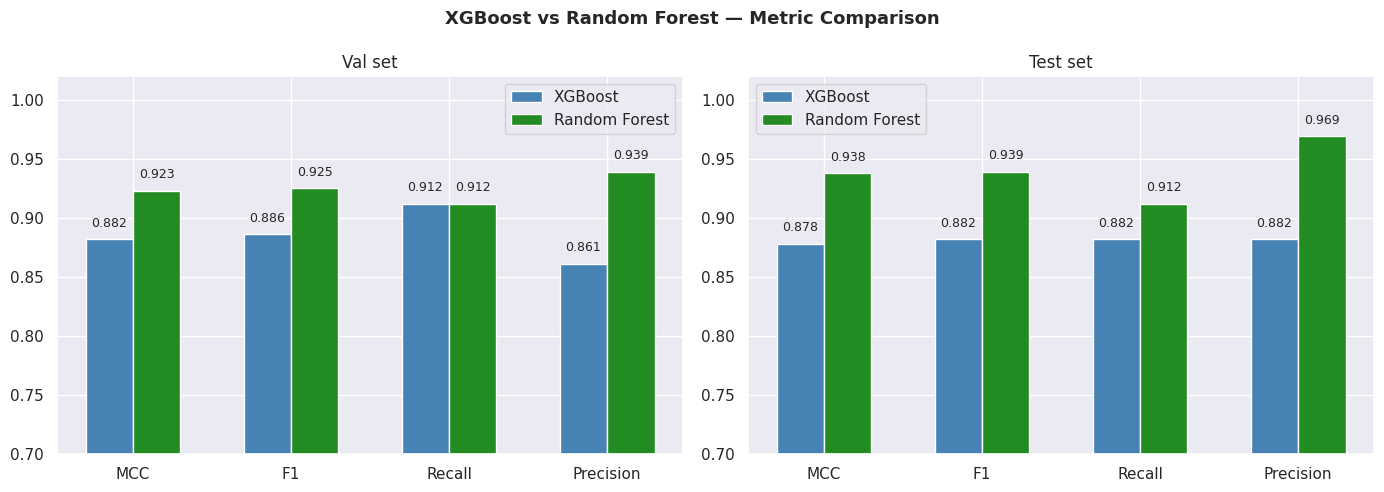

In [3]:
metrics = ['MCC', 'F1', 'Recall', 'Precision']
x = np.arange(len(metrics))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in [(axes[0], 'val'), (axes[1], 'test')]:
    xgb_row = summary[summary.Model.str.contains('XGB') & summary.Model.str.contains(split)].iloc[0]
    rf_row  = summary[summary.Model.str.contains('RF')  & summary.Model.str.contains(split)].iloc[0]

    xgb_vals = [xgb_row[m] for m in metrics]
    rf_vals  = [rf_row[m]  for m in metrics]

    b1 = ax.bar(x - w/2, xgb_vals, w, label='XGBoost',       color='steelblue')
    b2 = ax.bar(x + w/2, rf_vals,  w, label='Random Forest',  color='forestgreen')

    for bars in [b1, b2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.7, 1.02)
    ax.set_title(f'{split.title()} set')
    ax.legend()

plt.suptitle('XGBoost vs Random Forest — Metric Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/model_comparison_bars.png', dpi=150)
plt.show()

## 3 · Threshold sweep overlay

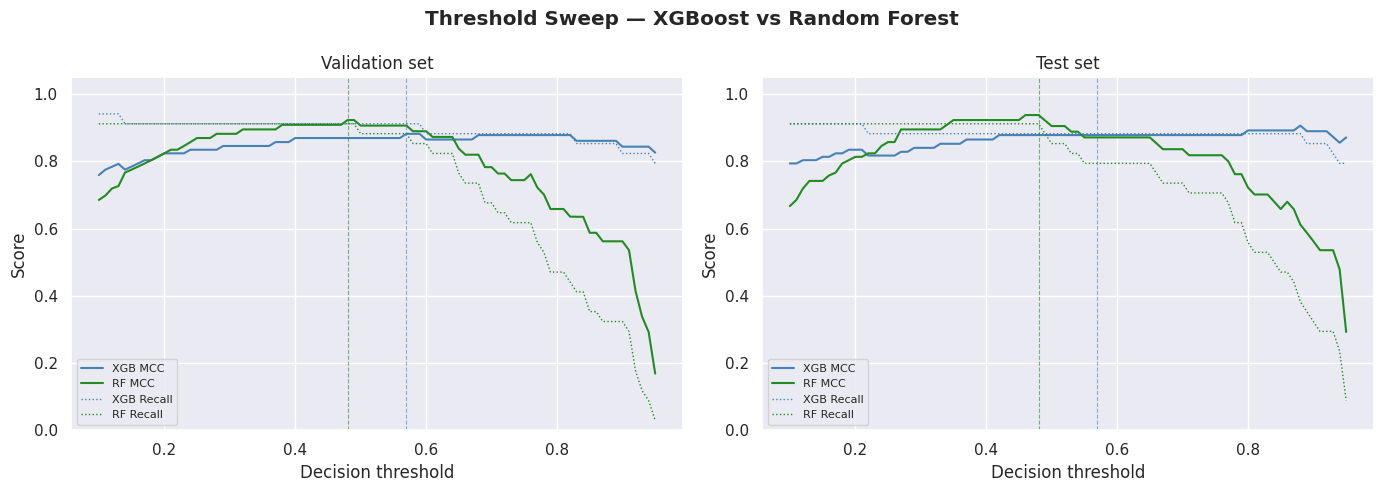

In [4]:
sweep_t = np.arange(0.10, 0.96, 0.01)

def sweep(model, X, y, thresholds):
    proba = model.predict_proba(X)[:, 1]
    rows = []
    for t in thresholds:
        yp = (proba >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'mcc': float(matthews_corrcoef(y, yp)),
            'recall': float(recall_score(y, yp, zero_division=0)),
        })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_s, y_s, title in [(axes[0], X_val, y_val, 'Validation'),
                              (axes[1], X_test, y_test, 'Test')]:
    xgb_s = sweep(xgb_model, X_s, y_s, sweep_t)
    rf_s  = sweep(rf_model,  X_s, y_s, sweep_t)

    ax.plot(xgb_s.threshold, xgb_s.mcc,    color='steelblue',  lw=1.5, label='XGB MCC')
    ax.plot(rf_s.threshold,  rf_s.mcc,     color='forestgreen', lw=1.5, label='RF MCC')
    ax.plot(xgb_s.threshold, xgb_s.recall, color='steelblue',  lw=1, ls=':', label='XGB Recall')
    ax.plot(rf_s.threshold,  rf_s.recall,  color='forestgreen', lw=1, ls=':', label='RF Recall')
    ax.axvline(xgb_thresh, color='steelblue',  ls='--', lw=0.8, alpha=0.6)
    ax.axvline(rf_thresh,  color='forestgreen', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{title} set')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

plt.suptitle('Threshold Sweep — XGBoost vs Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/model_comparison_threshold.png', dpi=150)
plt.show()

## 4 · Calibration comparison

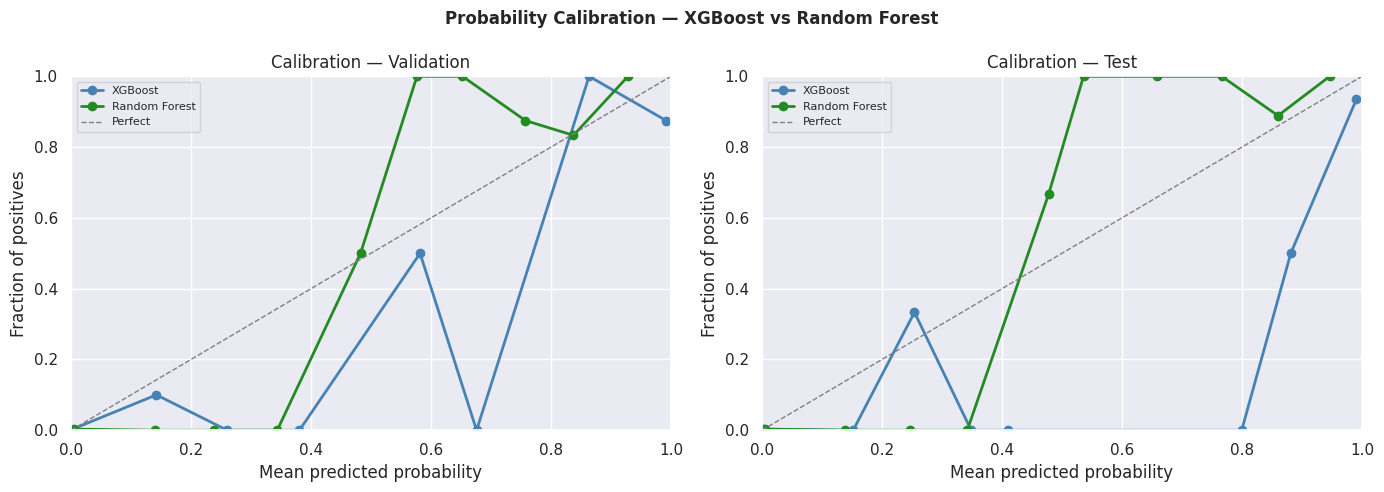

Brier scores (lower = better calibrated):
  XGBoost          Val: 0.0082   Test: 0.0076
  Random Forest    Val: 0.0070   Test: 0.0067


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_s, y_s, title in [(axes[0], X_val, y_val, 'Validation'),
                              (axes[1], X_test, y_test, 'Test')]:
    for model_obj, name, color in [
        (xgb_model, 'XGBoost', 'steelblue'),
        (rf_model,  'Random Forest', 'forestgreen'),
    ]:
        proba = model_obj.predict_proba(X_s)[:, 1]
        prob_true, prob_pred = calibration_curve(y_s, proba, n_bins=10, strategy='uniform')
        ax.plot(prob_pred, prob_true, 'o-', color=color, lw=2, label=name)

    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfect')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration — {title}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Probability Calibration — XGBoost vs Random Forest', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/model_comparison_calibration.png', dpi=150)
plt.show()

print('Brier scores (lower = better calibrated):')
for model_obj, name in [(xgb_model, 'XGBoost'), (rf_model, 'Random Forest')]:
    val_b  = brier_score_loss(y_val,  model_obj.predict_proba(X_val)[:, 1])
    test_b = brier_score_loss(y_test, model_obj.predict_proba(X_test)[:, 1])
    print(f'  {name:<15}  Val: {val_b:.4f}   Test: {test_b:.4f}')

## 5 · Miss analysis comparison

XGBoost:  caught 61, missed 7 (7/68 = 10.3% miss rate)
Random Forest:  caught 62, missed 6 (6/68 = 8.8% miss rate)


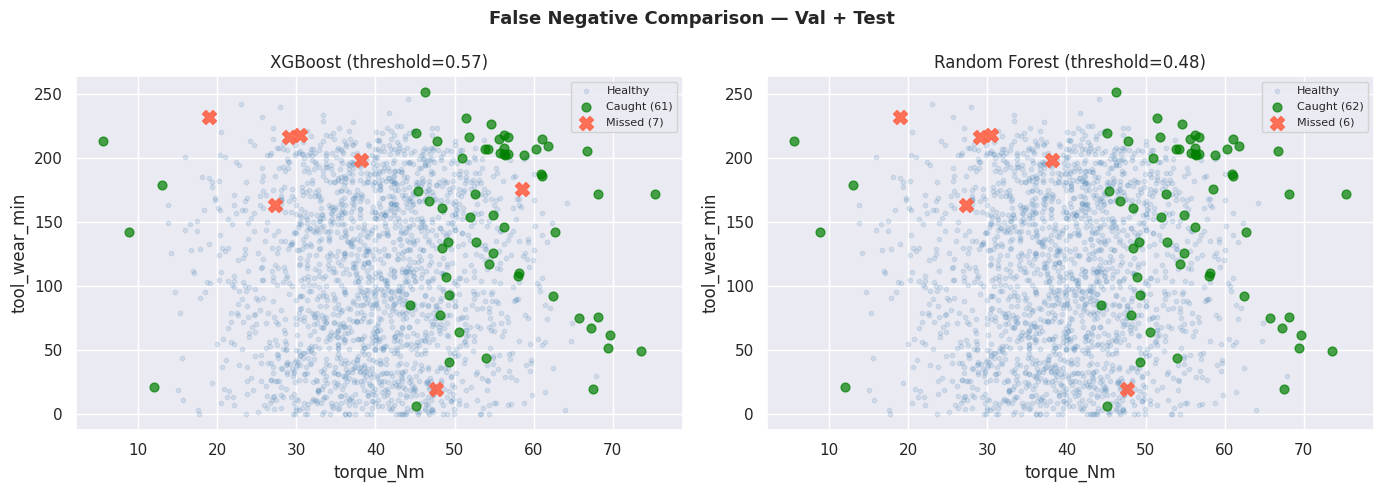

In [6]:
eval_X = pd.concat([X_val, X_test], ignore_index=True)
eval_y = pd.concat([y_val, y_test], ignore_index=True)

actual_fail = eval_y.values == 1

for model_obj, thresh, name, color in [
    (xgb_model, xgb_thresh, 'XGBoost',       'steelblue'),
    (rf_model,  rf_thresh,  'Random Forest',  'forestgreen'),
]:
    proba  = model_obj.predict_proba(eval_X)[:, 1]
    pred   = (proba >= thresh).astype(int)
    caught = actual_fail & (pred == 1)
    missed = actual_fail & (pred == 0)
    print(f'{name}:  caught {caught.sum()}, missed {missed.sum()} '
          f'({missed.sum()}/{actual_fail.sum()} = {missed.sum()/actual_fail.sum():.1%} miss rate)')

# Side-by-side scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
healthy = eval_y.values == 0

for ax, model_obj, thresh, name in [
    (axes[0], xgb_model, xgb_thresh, 'XGBoost'),
    (axes[1], rf_model,  rf_thresh,  'Random Forest'),
]:
    proba  = model_obj.predict_proba(eval_X)[:, 1]
    pred   = (proba >= thresh).astype(int)
    caught = actual_fail & (pred == 1)
    missed = actual_fail & (pred == 0)

    ax.scatter(eval_X[healthy]['torque_Nm'], eval_X[healthy]['tool_wear_min'],
               alpha=0.15, s=10, color='steelblue', label='Healthy')
    ax.scatter(eval_X[caught]['torque_Nm'],  eval_X[caught]['tool_wear_min'],
               alpha=0.7, s=40, color='green', label=f'Caught ({caught.sum()})', zorder=3)
    ax.scatter(eval_X[missed]['torque_Nm'],  eval_X[missed]['tool_wear_min'],
               alpha=0.9, s=100, color='tomato', label=f'Missed ({missed.sum()})',
               marker='X', zorder=4)
    ax.set_xlabel('torque_Nm')
    ax.set_ylabel('tool_wear_min')
    ax.set_title(f'{name} (threshold={thresh})')
    ax.legend(fontsize=8)

plt.suptitle('False Negative Comparison — Val + Test', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/model_comparison_misses.png', dpi=150)
plt.show()

## 6 · Summary

| Aspect | XGBoost | Random Forest | Winner |
|--------|---------|---------------|--------|
| Mean MCC | ~0.880 | ~0.930 | **RF** |
| Recall | ~0.897 | ~0.912 | **RF** |
| Precision | ~0.872 | ~0.954 | **RF** |

**Selected model: Random Forest**